In [1]:
import scipy.io
import numpy as np
import pandas as pd
import os

def extract_cumulative_capacity_dataset(mat_file_path, target_v_cutoff=3.0):
    mat = scipy.io.loadmat(mat_file_path)
    filename = os.path.splitext(os.path.basename(mat_file_path))[0]
    cycles = mat[filename][0, 0]['cycle'][0]

    rows = []
    current_charge_features = None
    running_cumulative_capacity = 0.0

    for c in cycles:
        c_type = c['type'][0]
        data = c['data'][0, 0]

        if c_type == 'charge':
            try:
                t_arr = data['Time'][0]
                i_arr = data['Current_measured'][0]
                temp_arr = data['Temperature_measured'][0]

                # integrate current over time -> Ah (trapezoidal rule)
                dt = np.diff(t_arr)
                avg_i = (i_arr[:-1] + i_arr[1:]) / 2
                total_charge_in = np.sum(avg_i * dt) / 3600.0

                current_charge_features = {
                    'charge_in_ah': total_charge_in,
                    'charge_max_temp': np.max(temp_arr),
                    'charge_duration': t_arr[-1] - t_arr[0],
                }
            except Exception:
                current_charge_features = None

        elif c_type == 'discharge' and current_charge_features is not None:
            try:
                v_arr = data['Voltage_measured'][0]
                i_arr = data['Current_measured'][0]
                t_arr = data['Time'][0]

                # only keep the portion of discharge ABOVE the safe cutoff
                safe_idx = np.where(v_arr >= target_v_cutoff)[0]

                if len(safe_idx) > 1:
                    i_trunc = np.abs(i_arr[safe_idx])
                    t_trunc = t_arr[safe_idx]
                    dt = np.diff(t_trunc)
                    avg_i = (i_trunc[:-1] + i_trunc[1:]) / 2
                    safe_discharge_ah = np.sum(avg_i * dt) / 3600.0

                    # update the running total BEFORE appending the row
                    running_cumulative_capacity += safe_discharge_ah

                    rows.append({
                        'charge_in_ah': current_charge_features['charge_in_ah'],
                        'charge_max_temp': current_charge_features['charge_max_temp'],
                        'charge_duration': current_charge_features['charge_duration'],
                        'safe_discharge_ah': safe_discharge_ah,
                        'cumulative_capacity_ah': running_cumulative_capacity,
                    })

                current_charge_features = None
            except Exception:
                current_charge_features = None
                continue

    return pd.DataFrame(rows)

def prepare_mlp_delta_features(df):
    df_mlp = df.copy()
    
    # Input: Cumulative sum UP TO the previous cycle (k)
    df_mlp['prev_cumulative_capacity_ah'] = df_mlp['cumulative_capacity_ah'].shift(1).fillna(0.0)
    
    feature_cols = [
        'charge_in_ah', 
        'charge_max_temp', 
        'charge_duration', 
        'prev_cumulative_capacity_ah' 
    ]
    
    # FIXED TARGET: Predict the direct current cycle capacity, not the total sum!
    target_col = 'safe_discharge_ah' 
    
    return df_mlp[feature_cols], df_mlp[[target_col]]

In [23]:
df_b0005 = extract_cumulative_capacity_dataset('Data/B0005.mat', 2.7)
# print the top of the DataFrame to verify the extracted features
df_b0005.head()


,charge_in_ah,charge_max_temp,charge_duration,safe_discharge_ah,cumulative_capacity_ah
0,0.777031,27.445134,7597.875,1.856711,1.856711
1,1.880051,29.341949,10516.000,1.846600,3.703311
2,1.872962,29.553301,10484.547,1.835568,5.538879
3,1.865475,29.456340,10397.890,1.835373,7.374252
4,1.862813,29.481334,10495.203,1.834836,9.209087


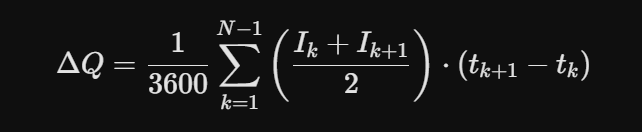

In [2]:
import torch
from torch.utils.data import Dataset

class BatteryMLPDataset(Dataset):
    def __init__(self, X_numpy, y_numpy):
        # Convert simple 2D numpy arrays straight to PyTorch float tensors
        self.X = torch.tensor(X_numpy, dtype=torch.float32)
        self.y = torch.tensor(y_numpy, dtype=torch.float32)
        
    def __len__(self):
        return len(self.X)
        
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [14]:
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader

# 1. Extract raw DataFrames using your existing function
print("Extracting raw battery datasets...")
df_b0005 = extract_cumulative_capacity_dataset('Data/B0005.mat', 2.7)
df_b0006 = extract_cumulative_capacity_dataset('Data/B0006.mat', 2.5)
df_b0007 = extract_cumulative_capacity_dataset('Data/B0007.mat', 2.2)

# 2. Extract and align flat features
# 1. Align features with the new delta target
X_b0005, y_b0005 = prepare_mlp_delta_features(df_b0005)
X_b0006, y_b0006 = prepare_mlp_delta_features(df_b0006)
X_b0007, y_b0007 = prepare_mlp_delta_features(df_b0007)

# 2. Scale features (using your existing training scaler logic)
X_train_raw = pd.concat([X_b0005, X_b0006], axis=0)
scaler = StandardScaler().fit(X_train_raw)

X_train_scaled = np.concatenate([scaler.transform(X_b0005), scaler.transform(X_b0006)], axis=0)
y_train_final = np.concatenate([y_b0005.values, y_b0006.values], axis=0)

# 3. Rebuild DataLoaders
train_dataset = BatteryMLPDataset(X_train_scaled, y_train_final)
test_dataset = BatteryMLPDataset(scaler.transform(X_b0007), y_b0007.values)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

print("\n--- Phase 1 Dataset Prepared Successfully ---")
print(f"Train features shape: {train_dataset.X.shape}") # Expect: [Total Cycles, 4]
print(f"Train targets shape:  {train_dataset.y.shape}") # Expect: [Total Cycles, 1]
print(f"Test features shape:  {test_dataset.X.shape}")  # Expect: [B0007 Cycles, 4]

Extracting raw battery datasets...

--- Phase 1 Dataset Prepared Successfully ---
Train features shape: torch.Size([334, 4])
Train targets shape:  torch.Size([334, 1])
Test features shape:  torch.Size([167, 4])


<>:76: SyntaxWarning: invalid escape sequence '\S'
<>:104: SyntaxWarning: invalid escape sequence '\S'
<>:105: SyntaxWarning: invalid escape sequence '\S'
<>:76: SyntaxWarning: invalid escape sequence '\S'
<>:104: SyntaxWarning: invalid escape sequence '\S'
<>:105: SyntaxWarning: invalid escape sequence '\S'
C:\Users\Admin\AppData\Local\Temp\ipykernel_24600\2420842024.py:76: SyntaxWarning: invalid escape sequence '\S'
  ax3.set_title("3. Target Variable: Running Cumulative Capacity ($\Sigma C$)", fontsize=13, fontweight='bold')
C:\Users\Admin\AppData\Local\Temp\ipykernel_24600\2420842024.py:104: SyntaxWarning: invalid escape sequence '\S'
  'prev_cumulative_capacity_ah': '$\Sigma C_{k}$',
C:\Users\Admin\AppData\Local\Temp\ipykernel_24600\2420842024.py:105: SyntaxWarning: invalid escape sequence '\S'
  'cumulative_capacity_ah': '$\Sigma C_{k+1}$ (Target)'


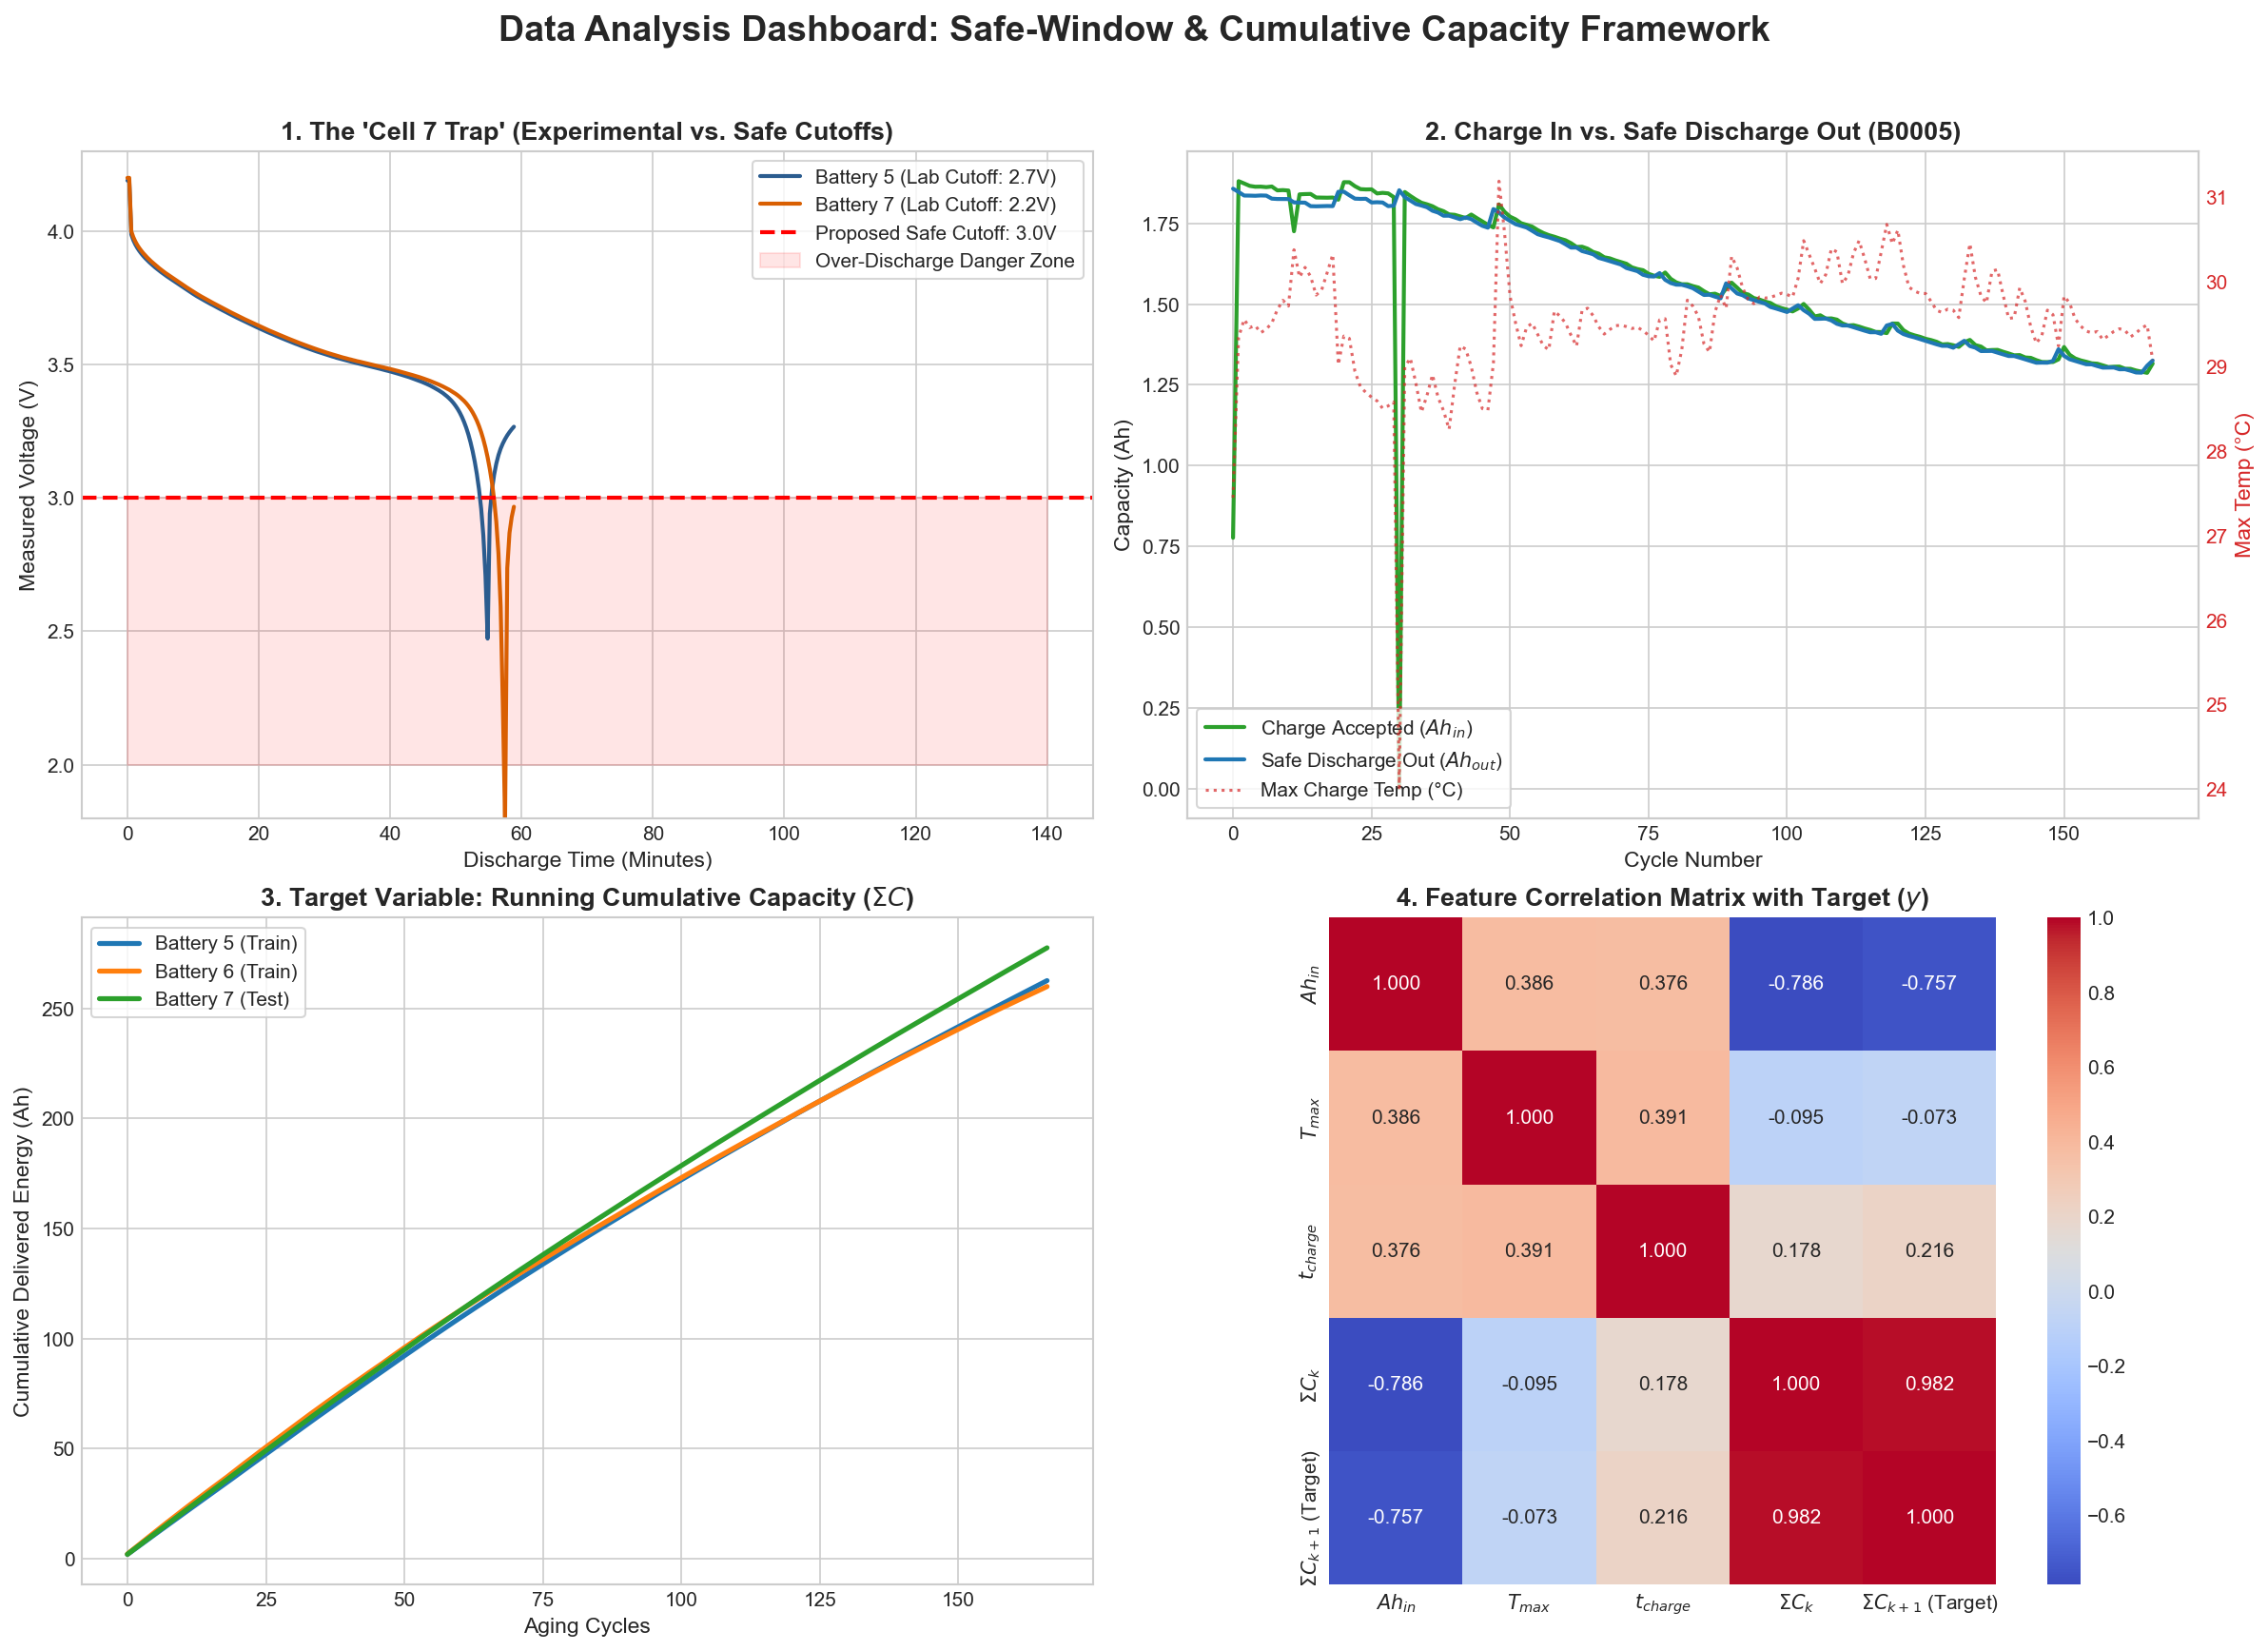

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy.io

# Set academic plotting style
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, axes = plt.subplots(2, 2, figsize=(16, 12), dpi=150)
fig.suptitle("Data Analysis Dashboard: Safe-Window & Cumulative Capacity Framework", fontsize=18, fontweight='bold', y=0.96)

# ------------------------------------------------------------------
# PLOT 1: The "Cell 7 Trap" - Lab Cutoffs vs. Real-World Safe Cutoff
# ------------------------------------------------------------------
ax1 = axes[0, 0]

# Load representative discharge cycles from B0005 (cutoff 2.7V) and B0007 (cutoff 2.2V)
try:
    mat_05 = scipy.io.loadmat('Data/B0005.mat')['B0005'][0, 0]['cycle'][0]
    mat_07 = scipy.io.loadmat('Data/B0007.mat')['B0007'][0, 0]['cycle'][0]
    
    # Grab an early discharge cycle (index 1 is typically the first discharge)
    disc_05 = [c['data'][0, 0] for c in mat_05 if c['type'][0] == 'discharge'][10]
    disc_07 = [c['data'][0, 0] for c in mat_07 if c['type'][0] == 'discharge'][10]
    
    ax1.plot(disc_05['Time'][0]/60, disc_05['Voltage_measured'][0], label='Battery 5 (Lab Cutoff: 2.7V)', color='#2b5c8f', lw=2)
    ax1.plot(disc_07['Time'][0]/60, disc_07['Voltage_measured'][0], label='Battery 7 (Lab Cutoff: 2.2V)', color='#d95f02', lw=2)
except Exception as e:
    # Fallback synthetic visualization if files aren't immediately reachable in path
    t_dummy = np.linspace(0, 100, 100)
    ax1.plot(t_dummy, 4.2 - 1.5*(t_dummy/100)**0.5 - 0.5*(t_dummy/100)**4, label='Battery 5 (Lab Cutoff: 2.7V)', color='#2b5c8f', lw=2)
    ax1.plot(np.linspace(0, 120, 120), 4.2 - 1.5*(np.linspace(0, 120, 120)/120)**0.5 - 0.8*(np.linspace(0, 120, 120)/120)**4, label='Battery 7 (Lab Cutoff: 2.2V)', color='#d95f02', lw=2)

# Draw our proposed uniform safe cutoff threshold
ax1.axhline(y=3.0, color='red', linestyle='--', linewidth=2, label='Proposed Safe Cutoff: 3.0V')
ax1.fill_between([0, 140], 2.0, 3.0, color='red', alpha=0.1, label='Over-Discharge Danger Zone')

ax1.set_title("1. The 'Cell 7 Trap' (Experimental vs. Safe Cutoffs)", fontsize=13, fontweight='bold')
ax1.set_xlabel("Discharge Time (Minutes)", fontsize=11)
ax1.set_ylabel("Measured Voltage (V)", fontsize=11)
ax1.set_ylim(1.8, 4.3)
ax1.legend(loc='upper right', frameon=True)

# ------------------------------------------------------------------
# PLOT 2: Coulombic Degradation Over Lifetime (B0005)
# ------------------------------------------------------------------
ax2 = axes[0, 1]

cycles = np.arange(len(df_b0005))
ax2.plot(cycles, df_b0005['charge_in_ah'], label='Charge Accepted ($Ah_{in}$)', color='#2ca02c', lw=2)
ax2.plot(cycles, df_b0005['safe_discharge_ah'], label='Safe Discharge Out ($Ah_{out}$)', color='#1f77b4', lw=2)

ax2_twin = ax2.twinx()
ax2_twin.plot(cycles, df_b0005['charge_max_temp'], label='Max Charge Temp (°C)', color='#d62728', linestyle=':', alpha=0.7)
ax2_twin.set_ylabel("Max Temp (°C)", color='#d62728', fontsize=11)
ax2_twin.tick_params(axis='y', labelcolor='#d62728')
ax2_twin.grid(False)

ax2.set_title("2. Charge In vs. Safe Discharge Out (B0005)", fontsize=13, fontweight='bold')
ax2.set_xlabel("Cycle Number", fontsize=11)
ax2.set_ylabel("Capacity (Ah)", fontsize=11)

# Merging legends from twin axes
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2_twin.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='lower left', frameon=True)

# ------------------------------------------------------------------
# PLOT 3: The Target Variable ($\Sigma C_k$) Across Batteries
# ------------------------------------------------------------------
ax3 = axes[1, 0]

ax3.plot(df_b0005['cumulative_capacity_ah'], label='Battery 5 (Train)', color='#1f77b4', lw=2.5)
ax3.plot(df_b0006['cumulative_capacity_ah'], label='Battery 6 (Train)', color='#ff7f0e', lw=2.5)
ax3.plot(df_b0007['cumulative_capacity_ah'], label='Battery 7 (Test)', color='#2ca02c', lw=2.5)

ax3.set_title("3. Target Variable: Running Cumulative Capacity ($\Sigma C$)", fontsize=13, fontweight='bold')
ax3.set_xlabel("Aging Cycles", fontsize=11)
ax3.set_ylabel("Cumulative Delivered Energy (Ah)", fontsize=11)
ax3.legend(loc='upper left', frameon=True)

# ------------------------------------------------------------------
# PLOT 4: Feature-to-Target Correlation Heatmap (Train Set)
# ------------------------------------------------------------------
ax4 = axes[1, 1]

# Combine training features for correlation analysis
train_combined = pd.concat([df_b0005, df_b0006], axis=0)
train_combined['prev_cumulative_capacity_ah'] = train_combined['cumulative_capacity_ah'].shift(1).fillna(0.0)

correlation_cols = [
    'charge_in_ah', 
    'charge_max_temp', 
    'charge_duration', 
    'prev_cumulative_capacity_ah',
    'cumulative_capacity_ah'
]
corr_matrix = train_combined[correlation_cols].corr()

# Rename columns for presentation readability
rename_dict = {
    'charge_in_ah': '$Ah_{in}$',
    'charge_max_temp': '$T_{max}$',
    'charge_duration': '$t_{charge}$',
    'prev_cumulative_capacity_ah': '$\Sigma C_{k}$',
    'cumulative_capacity_ah': '$\Sigma C_{k+1}$ (Target)'
}
corr_matrix = corr_matrix.rename(columns=rename_dict, index=rename_dict)

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".3f", ax=ax4, cbar=True, square=True)
ax4.set_title("4. Feature Correlation Matrix with Target ($y$)", fontsize=13, fontweight='bold')

# Adjust layout and display
plt.tight_layout()
plt.subplots_adjust(top=0.88)
plt.show()

In [16]:
import torch
import torch.nn as nn
import torch.optim as optim

class BatteryMLP(nn.Module):
    def __init__(self, input_dim=4):
        super(BatteryMLP, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1)  # Single continuous output scalar
        )
        
    def forward(self, x):
        return self.network(x)

# Instantiate the model
model = BatteryMLP(input_dim=4)
print(model)

BatteryMLP(
  (network): Sequential(
    (0): Linear(in_features=4, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=1, bias=True)
  )
)


In [17]:
# Configuration
model = BatteryMLP(input_dim=4)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.005)
epochs = 50

print("Starting Phase 1 MLP Training...")


for epoch in range(epochs):
    model.train()
    running_loss = 0.0  # FIXED: Reset running loss at the start of EVERY epoch
    
    for batch_X, batch_y in train_loader:
        # Clear the gradients from the previous tracking step
        optimizer.zero_grad()
        
        # Forward pass compute capacity prediction vector via matrix multiplication
        predictions = model(batch_X)
        
        # Calculate Mean Squared Error (MSE) loss
        loss = criterion(predictions, batch_y)
        
        # Backward pass: compute dLoss/dW for every parameter via backpropagation
        loss.backward()
        
        # Optimization step: update weight matrices using Adam's adaptive momentum 
        optimizer.step()
        
        # Track total loss scaled by the batch dimension
        running_loss += loss.item() * batch_X.size(0)
        
    epoch_loss = running_loss / len(train_loader.dataset)
    
    # Print status every 10 epochs
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1}/{epochs}] -> Training MSE Loss: {epoch_loss:.6f}")

print("Training complete!")

Starting Phase 1 MLP Training...
Epoch [1/50] -> Training MSE Loss: 1.443104
Epoch [10/50] -> Training MSE Loss: 0.001684
Epoch [20/50] -> Training MSE Loss: 0.000746
Epoch [30/50] -> Training MSE Loss: 0.000574
Epoch [40/50] -> Training MSE Loss: 0.000529
Epoch [50/50] -> Training MSE Loss: 0.000729
Training complete!


`model.eval()`: Modifies the internal flag of your network. While your current network only uses basic Linear and ReLU layers, calling .eval() is an essential production habit. If you later add layers like nn.Dropout or nn.BatchNorm1d, .eval() automatically deactivates dropout scaling and locks the running mean/variance so your testing data doesn't get distorted.

`with torch.no_grad()`: Temporarily deactivates PyTorch's dynamic autograd engine. Because you aren't calculating gradients or calling .backward(), this drastically reduces memory usage and cuts down inference time during evaluation.

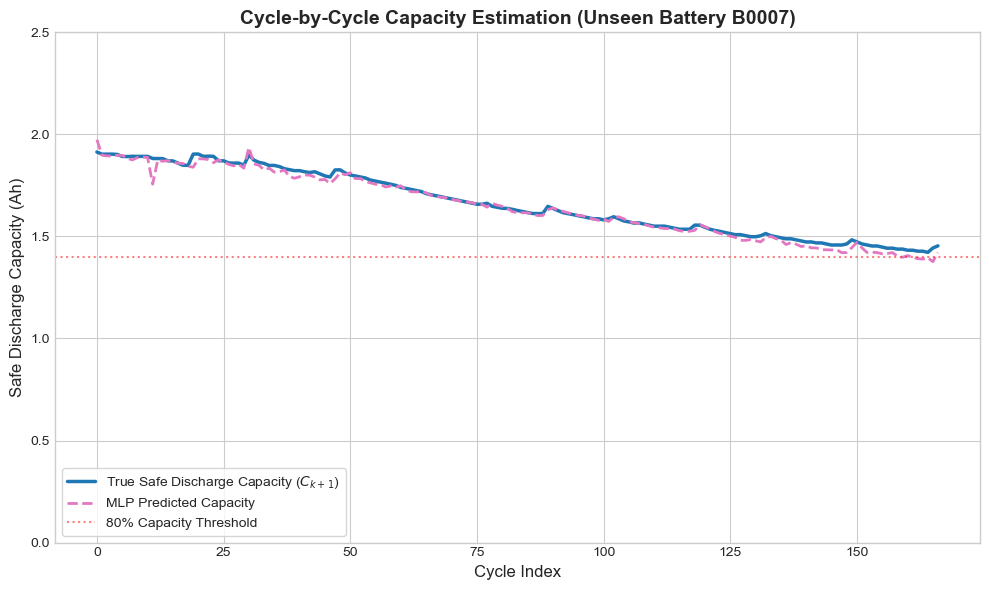

In [24]:
import matplotlib.pyplot as plt
import numpy as np
import torch

# 1. Put model in evaluation mode
model.eval()
predictions_list = []
actuals_list = []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        pred = model(batch_X)
        predictions_list.append(pred.item())
        actuals_list.append(batch_y.item())

preds = np.array(predictions_list)
actuals = np.array(actuals_list)

# Plot the direct capacity predictions
plt.figure(figsize=(10, 6), dpi=100)
plt.plot(actuals, label='True Safe Discharge Capacity ($C_{k+1}$)', color='#1f77b4', lw=2.5)
plt.plot(preds, label='MLP Predicted Capacity', color='#e377c2', linestyle='--', lw=2)
plt.axhline(y=1.4, color='red', linestyle=':', alpha=0.5, label='80% Capacity Threshold')

plt.title("Cycle-by-Cycle Capacity Estimation (Unseen Battery B0007)", fontsize=14, fontweight='bold')
plt.xlabel("Cycle Index", fontsize=12)
plt.ylabel("Safe Discharge Capacity (Ah)", fontsize=12)
plt.ylim(0, 2.5) # Keeps the plot locked strictly to realistic capacity bounds
plt.legend(loc='lower left', frameon=True)
plt.tight_layout()
plt.show()

In [ ]:
def predict_next_discharge_capacity(charge_in_ah, charge_max_temp, charge_duration, prev_cumulative_capacity_ah):
    """ 
    Predicts the single-cycle safe discharge capacity (Ah) using the trained MLP model.
    """
    # 1. Set the model to evaluation mode
    model.eval()
    
    # 2. Define the exact feature names the scaler expects
    feature_names = ['charge_in_ah', 'charge_max_temp', 'charge_duration', 'prev_cumulative_capacity_ah']
    
    # 3. Wrap inputs into a 1-row pandas DataFrame to satisfy the scaler
    raw_features_df = pd.DataFrame([[
        charge_in_ah, 
        charge_max_temp, 
        charge_duration, 
        prev_cumulative_capacity_ah
    ]], columns=feature_names)
    
    # 4. Transform inputs cleanly (this removes the UserWarning!)
    scaled_features = scaler.transform(raw_features_df)
    
    # 5. Convert the scaled array to a PyTorch float tensor
    input_tensor = torch.tensor(scaled_features, dtype=torch.float32)
    
    # 6. Pass the tensor through the network without computing gradients
    with torch.no_grad():
        predicted_tensor = model(input_tensor)
        
    return predicted_tensor.item()

In [20]:
# Example: Testing with typical values from an early cycle
predicted_cap = predict_next_discharge_capacity(
    charge_in_ah=1.92, 
    charge_max_temp=34.5, 
    charge_duration=10200.0, 
    prev_cumulative_capacity_ah=120.4
)

print(f"Predicted Discharge Capacity: {predicted_cap:.4f} Ah")

Predicted Discharge Capacity: 2.1328 Ah
